In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('placement.csv')

In [3]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [4]:
df.shape

(1000, 3)

In [5]:
df.sample(5)

,cgpa,placement_exam_marks,placed
470,6.46,28.0,0
27,6.53,46.0,0
458,7.13,47.0,0
252,6.24,54.0,1
89,6.56,17.0,0


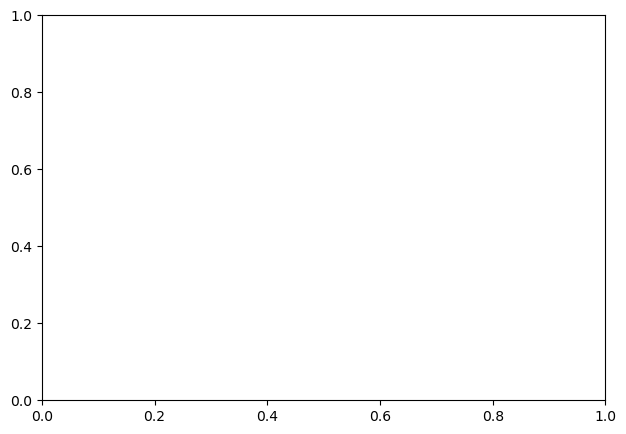

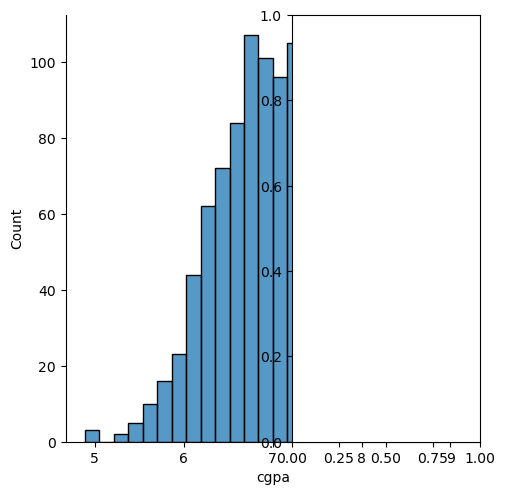

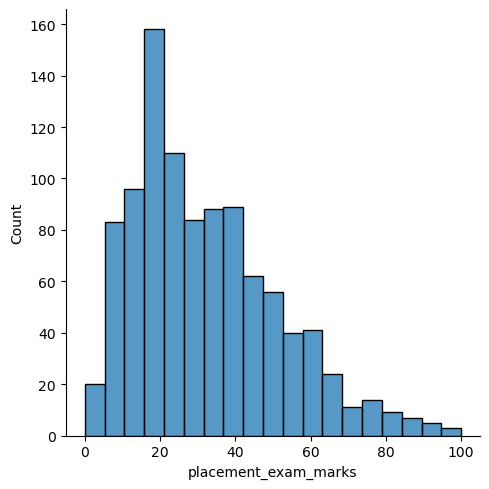

In [6]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.displot(df['cgpa'])

plt.subplot(1,2,2)
sns.displot(df['placement_exam_marks'])

plt.show()

In [7]:
df['placement_exam_marks'].skew()

0.8356419499466834

In [8]:
df['cgpa'].skew()

-0.014529938929314918

In [9]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323894
Min value of cgpa 4.89
Max value of cgpa 9.12


In [10]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

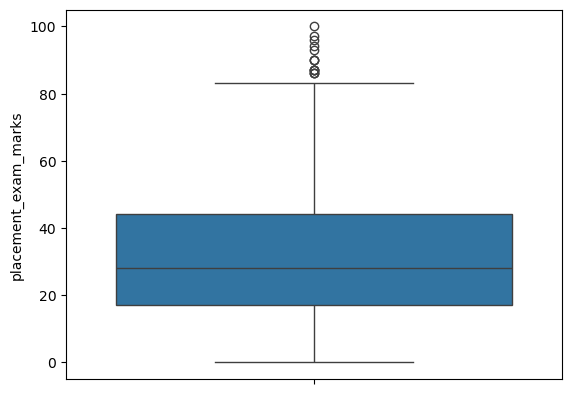

In [11]:
sns.boxplot(df['placement_exam_marks'])

In [12]:
#Finding the Inter Quartile Range(IQR)

In [14]:
percentile25=df['placement_exam_marks'].quantile(0.25)
percentile75=df['placement_exam_marks'].quantile(0.75)

In [15]:

percentile75

44.0

In [16]:
iqr=percentile75-percentile25

In [17]:
iqr

27.0

In [18]:
upper_limit=percentile75 +1.5*iqr
lower_limit=percentile25 -1.5*iqr

In [19]:
upper_limit

84.5

In [20]:
lower_limit

-23.5

In [21]:
#Finding the outliers

In [22]:
df[df['placement_exam_marks']>upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [24]:
df[df['placement_exam_marks']<lower_limit]

,cgpa,placement_exam_marks,placed


In [25]:
#Trimming

In [26]:
new_df=df[df['placement_exam_marks']<upper_limit]


In [27]:
new_df.shape

(985, 3)

In [28]:
#Comparing

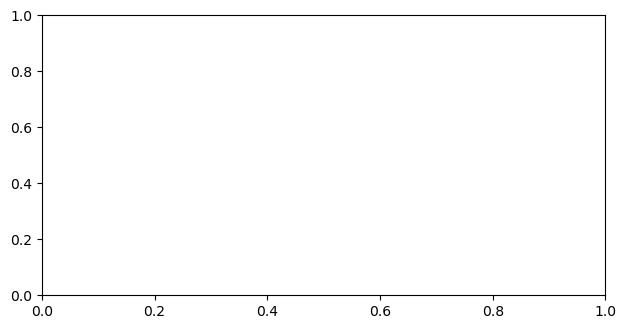

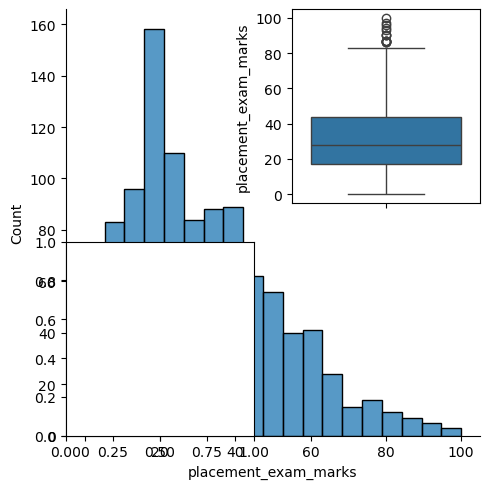

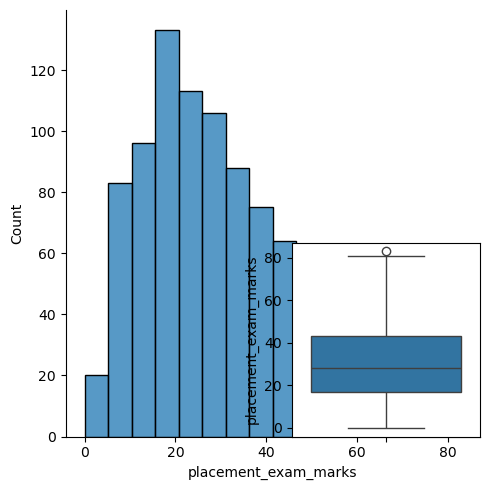

In [29]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.displot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.displot(new_df['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])

plt.show()

In [30]:
#Caping:-

In [32]:
new_df_cap=df.copy()

new_df_cap['placement_exam_marks']=np.where(
    new_df_cap['placement_exam_marks']>upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks']<lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)
        
        

In [33]:
new_df_cap.shape

(1000, 3)

In [34]:
#Comparing

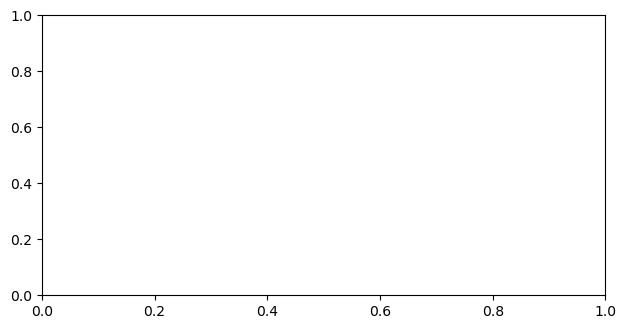

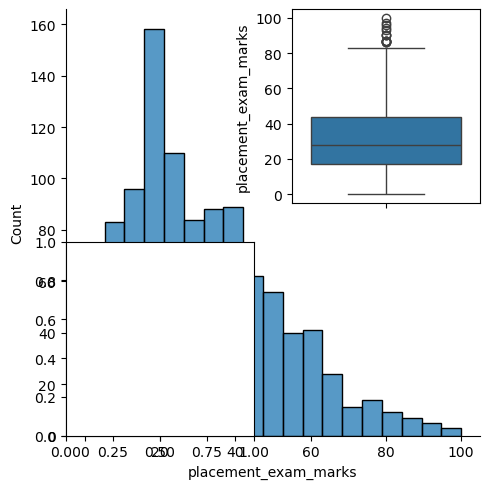

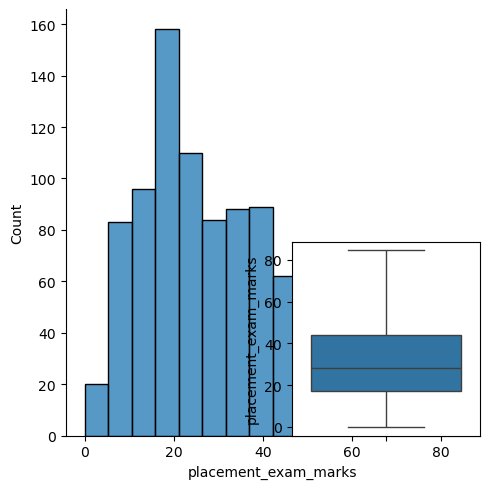

In [37]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.displot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.displot(new_df_cap['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'])

plt.show()